<a href="https://colab.research.google.com/github/GinaldoDSSilva/ImersaoPythonAula/blob/main/Imersao_Python_aula_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
dados = yf.download('PETR4.SA', start='2023-01-01', end='2023-12-31')
dados

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2023-01-02,14.456954,15.018327,14.381263,14.848024,78424700
2023-01-03,14.091115,14.570491,13.958655,14.469570,96750300
2023-01-04,14.538952,14.879561,13.769429,13.851426,129504000
2023-01-05,15.062480,15.163402,14.602028,14.721872,73886000
2023-01-06,14.974173,15.340012,14.854328,15.100324,51851500
...,...,...,...,...,...
2023-12-21,29.720171,29.957018,29.458823,29.948850,30511900
2023-12-22,30.006020,30.055020,29.703834,29.810007,31234700


In [4]:
dados.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']
dados

,Abertura,Máxima,Mínima,Fechamento,Volume
Date,,,,,
2023-01-02,14.456954,15.018327,14.381263,14.848024,78424700
2023-01-03,14.091115,14.570491,13.958655,14.469570,96750300
2023-01-04,14.538952,14.879561,13.769429,13.851426,129504000
2023-01-05,15.062480,15.163402,14.602028,14.721872,73886000
2023-01-06,14.974173,15.340012,14.854328,15.100324,51851500
...,...,...,...,...,...
2023-12-21,29.720171,29.957018,29.458823,29.948850,30511900
2023-12-22,30.006020,30.055020,29.703834,29.810007,31234700
2023-12-26,30.487883,30.520549,30.079526,30.104027,23466800


In [5]:
dados = dados.rename_axis('Data')
dados

,Abertura,Máxima,Mínima,Fechamento,Volume
Data,,,,,
2023-01-02,14.456954,15.018327,14.381263,14.848024,78424700
2023-01-03,14.091115,14.570491,13.958655,14.469570,96750300
2023-01-04,14.538952,14.879561,13.769429,13.851426,129504000
2023-01-05,15.062480,15.163402,14.602028,14.721872,73886000
2023-01-06,14.974173,15.340012,14.854328,15.100324,51851500
...,...,...,...,...,...
2023-12-21,29.720171,29.957018,29.458823,29.948850,30511900
2023-12-22,30.006020,30.055020,29.703834,29.810007,31234700
2023-12-26,30.487883,30.520549,30.079526,30.104027,23466800


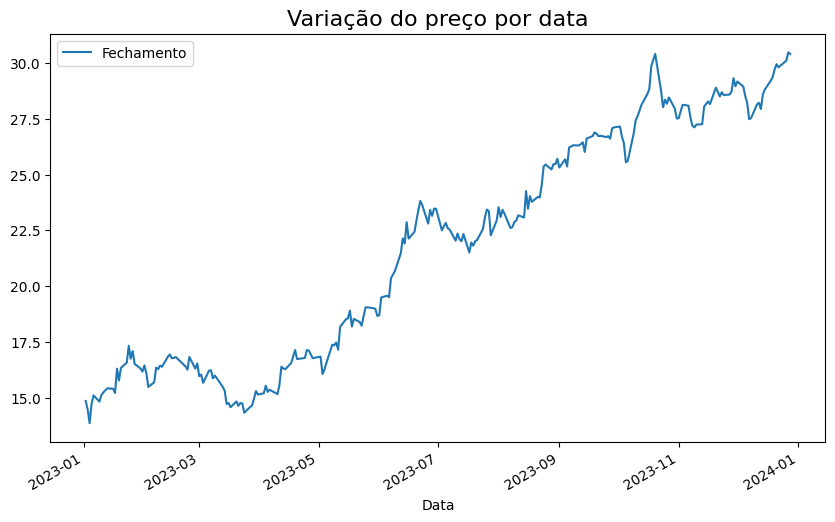

In [6]:
dados['Fechamento'].plot(figsize=(10,6))
plt.title('Variação do preço por data', fontsize=16)
plt.legend(['Fechamento'])

In [7]:
df = dados.head(60).copy()

# Convertendo o índice em uma coluna de data
df['Data'] = df.index

# Convertendo as datas para o formato numérico de matplotlib
# Isso é necessário para que o Matplotlib possa plotar as datas corretamente no gráfico
df['Data'] = df['Data'].apply(mdates.date2num)

df

,Abertura,Máxima,Mínima,Fechamento,Volume,Data
Data,,,,,,
2023-01-02,14.456954,15.018327,14.381263,14.848024,78424700,19359.0
2023-01-03,14.091115,14.570491,13.958655,14.469570,96750300,19360.0
2023-01-04,14.538952,14.879561,13.769429,13.851426,129504000,19361.0
2023-01-05,15.062480,15.163402,14.602028,14.721872,73886000,19362.0
2023-01-06,14.974173,15.340012,14.854328,15.100324,51851500,19363.0
2023-01-09,15.056175,15.138173,14.665105,14.822795,46385200,19366.0
2023-01-10,15.194938,15.207553,14.740793,15.106632,52741100,19367.0
2023-01-11,15.314785,15.529243,15.169710,15.232786,53536500,19368.0
2023-01-12,15.535548,15.548164,15.207555,15.321092,58130000,19369.0


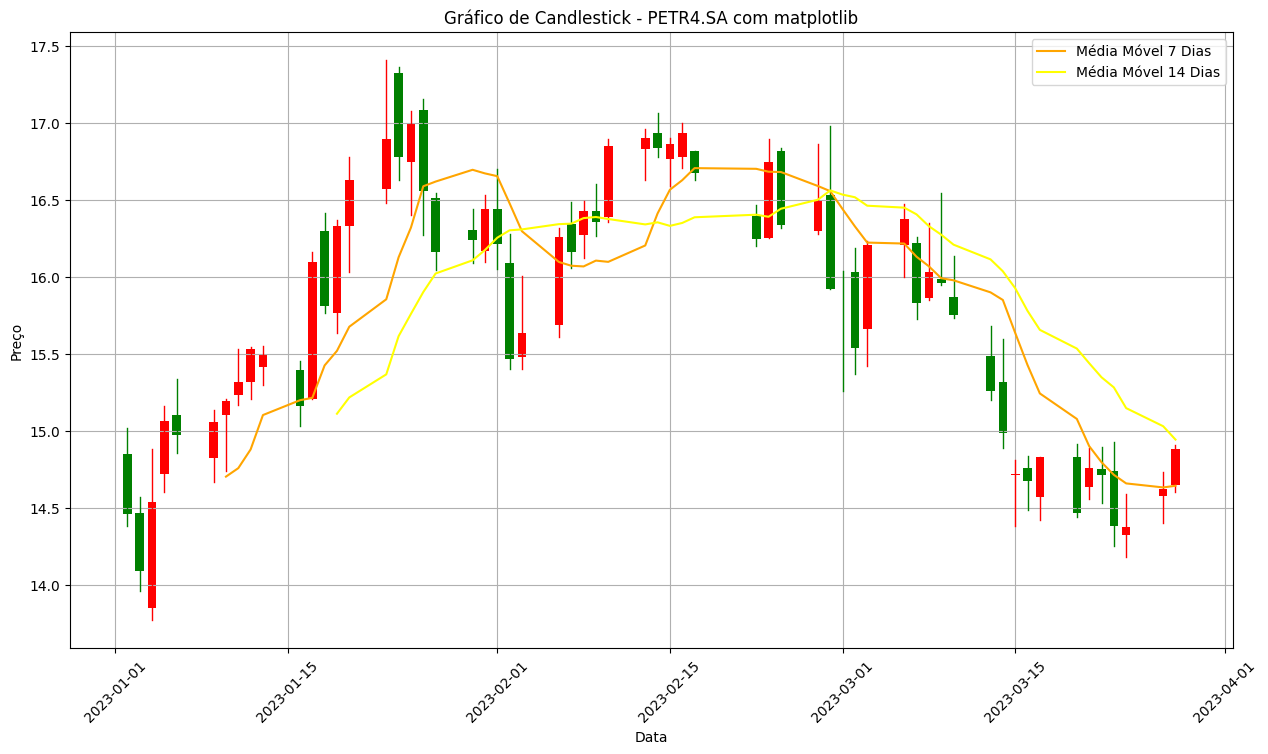

In [8]:
fig, ax = plt.subplots(figsize=(15, 8))

# Vamos definir a largura dos candles no gráfico
width = 0.7

for i in range(len(df)):
    # Determinando a cor do candle
    # Se o preço de fechamento for maior que o de abertura, o candle é verde (a ação valorizou nesse dia).
    # Se for menor, o candle é vermelho (a ação desvalorizou).
    if df['Fechamento'].iloc[i] > df['Abertura'].iloc[i]:
        color = 'green'
    else:
        color = 'red'

    # Desenhando a linha vertical do candle (mecha)
    # Essa linha mostra os preços máximo (topo da linha) e mínimo (base da linha) do dia.
    # Usamos `ax.plot` para desenhar uma linha vertical.
    # [df['Data'].iloc[i], df['Data'].iloc[i]] define o ponto x da linha (a data), e [df['Mínimo'].iloc[i], df['Máximo'].iloc[i]] define a altura da linha.
    # Corrigindo os nomes das colunas para 'Mínima' e 'Máxima'
    ax.plot([df['Data'].iloc[i], df['Data'].iloc[i]],
            [df['Mínima'].iloc[i], df['Máxima'].iloc[i]], # Corrected column names
            color=color,
            linewidth=1)

    ax.add_patch(plt.Rectangle((df['Data'].iloc[i] - width/2, min(df['Abertura'].iloc[i], df['Fechamento'].iloc[i])),
                               width,
                               abs(df['Fechamento'].iloc[i] - df['Abertura'].iloc[i]),
                               facecolor=color))

df['MA7'] = df['Fechamento'].rolling(window=7).mean()
df['MA14'] = df['Fechamento'].rolling(window=14).mean()

# Plotando as médias móveis
ax.plot(df['Data'], df['MA7'], color='orange', label='Média Móvel 7 Dias')  # Média de 7 dias
ax.plot(df['Data'], df['MA14'], color='yellow', label='Média Móvel 14 Dias')  # Média de 14 dias
# Adicionando legendas para as médias móveis
ax.legend()

# Formatando o eixo x para mostrar as datas
# Configuramos o formato da data e a rotação para melhor legibilidade
ax.xaxis_date() #O método xaxis_date() é usado para dizer ao Matplotlib que as datas estão sendo usadas no eixo x
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Adicionando título e rótulos para os eixos x e y
plt.title("Gráfico de Candlestick - PETR4.SA com matplotlib")
plt.xlabel("Data")
plt.ylabel("Preço")

# Adicionando uma grade para facilitar a visualização dos valores
plt.grid(True)

# Exibindo o gráfico
plt.show()

In [9]:
# Criando subplots
'''
"Primeiro, criamos uma figura que conterá nossos gráficos usando make_subplots.
Isso nos permite ter múltiplos gráficos em uma única visualização.
Aqui, teremos dois subplots: um para o gráfico de candlestick e outro para o volume de transações."

'''
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.1,
                    subplot_titles=('Candlesticks', 'Volume Transacionado'),
                    row_width=[0.2, 0.7])

'''
"No gráfico de candlestick, cada candle representa um dia de negociação,
mostrando o preço de abertura, fechamento, máximo e mínimo. Vamos adicionar este gráfico à nossa figura."
'''
# Adicionando o gráfico de candlestick
# Corrected 'Maximo' to 'Máxima' and 'Minimo' to 'Mínima' to match column names
fig.add_trace(go.Candlestick(x=df.index,
                             open=df['Abertura'],
                             high=df['Máxima'],  # Corrected column name
                             low=df['Mínima'],  # Corrected column name
                             close=df['Fechamento'],
                             name='Candlestick'),
                             row=1, col=1)

# Adicionando as médias móveis
# Adicionamos também médias móveis ao mesmo subplot para análise de tendências
fig.add_trace(go.Scatter(x=df.index,
                         y=df['MA7'],
                         mode='lines',
                         name='MA7 - Média Móvel 7 Dias'),
                         row=1, col=1)

fig.add_trace(go.Scatter(x=df.index,
                         y=df['MA14'],
                         mode='lines',
                         name='MA14 - Média Móvel 14 Dias'),
                         row=1, col=1)

# Adicionando o gráfico de barras para o volume
# Em seguida, criamos um gráfico de barras para o volume de transações, que nos dá uma ideia da atividade de negociação naquele dia
fig.add_trace(go.Bar(x=df.index,
                     y=df['Volume'],
                     name='Volume'),
                     row=2, col=1)

# Atualizando layout
#Finalmente, configuramos o layout da figura, ajustando títulos, formatos de eixo e outras configurações para tornar o gráfico claro e legível.
fig.update_layout(yaxis_title='Preço',
                  xaxis_rangeslider_visible=False,  # Desativa o range slider
                  width=1100, height=600)

# Mostrando o gráfico
fig.show()

In [10]:
dados = yf.download('AAPL', start='2023-01-01', end='2023-12-31')
dados

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.632530,129.395518,122.742873,128.782649,112117500
2023-01-04,124.907700,127.181268,123.642412,125.431607,89113600
2023-01-05,123.583084,126.301477,123.326078,125.668834,80962700
2023-01-06,128.130234,128.792531,123.454601,124.561732,87754700
2023-01-09,128.654129,131.876670,128.397123,128.970458,70790800
...,...,...,...,...,...
2023-12-22,192.444595,194.243791,191.818350,194.015153,37122800
2023-12-26,191.897858,192.732841,191.679169,192.454513,28919300


In [11]:
dados.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']
dados

,Abertura,Máxima,Mínima,Fechamento,Volume
Date,,,,,
2023-01-03,123.632530,129.395518,122.742873,128.782649,112117500
2023-01-04,124.907700,127.181268,123.642412,125.431607,89113600
2023-01-05,123.583084,126.301477,123.326078,125.668834,80962700
2023-01-06,128.130234,128.792531,123.454601,124.561732,87754700
2023-01-09,128.654129,131.876670,128.397123,128.970458,70790800
...,...,...,...,...,...
2023-12-22,192.444595,194.243791,191.818350,194.015153,37122800
2023-12-26,191.897858,192.732841,191.679169,192.454513,28919300
2023-12-27,191.997269,192.345186,189.949565,191.341219,48087700


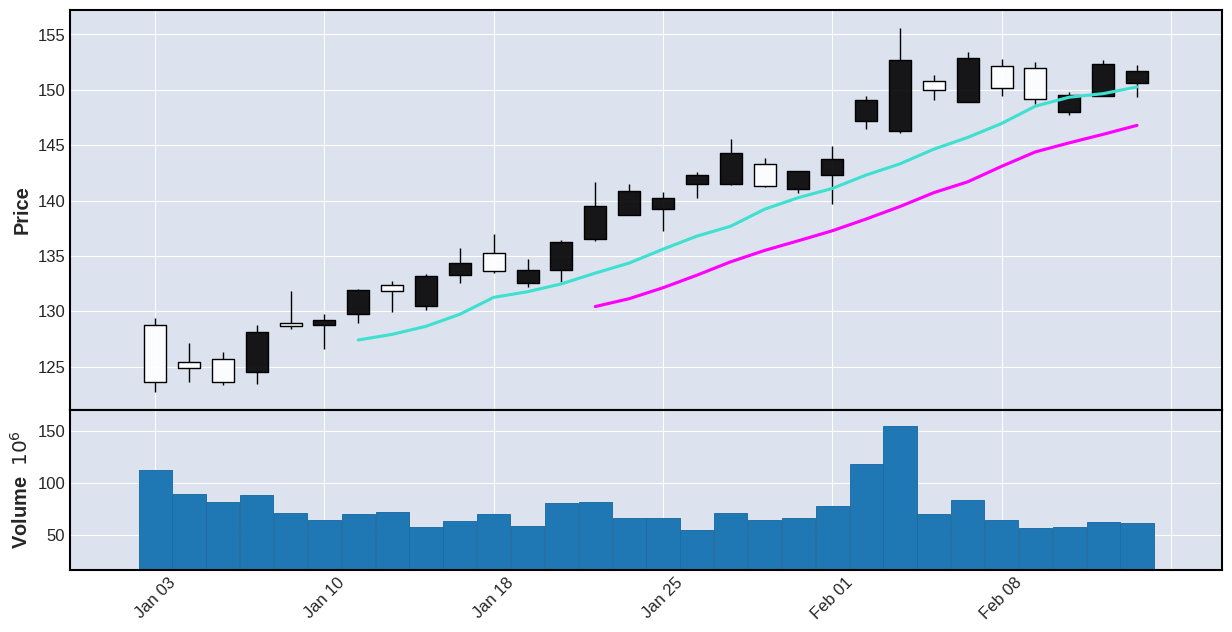

In [12]:
# Rename the columns to English before calling mpf.plot
dados.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Now plot the data
mpf.plot(dados.head(30), type='candle', figsize=(16, 8), volume=True, mav=(7, 14))